<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/ML-Project/Project_phase2_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI4I 2020 Predictive Maintenance – Six-Class Failure Classification

| | |
|---|---|
| **Dataset** | AI4I 2020 Predictive Maintenance Dataset (UCI ML Repository) |
| **Task** | Multi-class classification — No Failure + 5 failure types |
| **Model** | Random Forest with SMOTE oversampling for class imbalance |

---

### Failure classes
| Label | Class | Description |
|-------|-------|-------------|
| 0 | No Failure | Normal operation (~96.6 % of samples) |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |
| 5 | RNF | Random Failure |

## 0 · Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler, label_binarize
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)
from imblearn.over_sampling    import SMOTE

# Global reproducibility seed
SEED = 42
np.random.seed(SEED)

print("All imports successful.")

All imports successful.


---
## 1 · Load Data & Inspect Class Distribution

The raw CSV stores each failure mode as its own binary column (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`).  
We fold them into a **single six-class target** using a priority rule:  
`TWF → HDF → PWF → OSF → RNF → No Failure`  
so that any multi-failure sample gets exactly one canonical label.

In [8]:
dataset = fetch_ucirepo(id=601)
features = dataset.data.features
targets  = dataset.data.targets
df = pd.concat([features, targets], axis=1)
#df = dataset.data.original  # get the full original dataframe
#df.to_csv("ai4i2020.csv", index=False)
print("Dataset downloaded and saved as ai4i2020.csv")

#df = pd.read_csv("ai4i2020.csv")

print("Actual column names:")
print(df.columns.tolist())

print(f"\nDataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset downloaded and saved as ai4i2020.csv
Actual column names:
['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dataset shape: 10,000 rows x 12 columns


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
# ── Build the six-class target column ────────────────────────────────────────
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
class_names  = ["No Failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

def assign_class(row):
    """Return integer label 0-5.  First matching failure flag wins."""
    for idx, col in enumerate(failure_cols, start=1):
        if row[col] == 1:
            return idx
    return 0  # No Failure

df["target"] = df.apply(assign_class, axis=1)

# ── Print class distribution ──────────────────────────────────────────────────
dist = df["target"].value_counts().sort_index()

print(f"{'Class':<20} {'Count':>7}  {'Share':>7}")
print("-" * 40)
for cls_idx, count in dist.items():
    pct = 100 * count / len(df)
    print(f"{class_names[cls_idx]:<20} {count:>7,}  {pct:>6.2f}%")
print("-" * 40)
print(f"{'TOTAL':<20} {len(df):>7,}  100.00%")

Class                  Count    Share
----------------------------------------
No Failure             9,652   96.52%
TWF                       46    0.46%
HDF                      115    1.15%
PWF                       91    0.91%
OSF                       78    0.78%
RNF                       18    0.18%
----------------------------------------
TOTAL                 10,000  100.00%


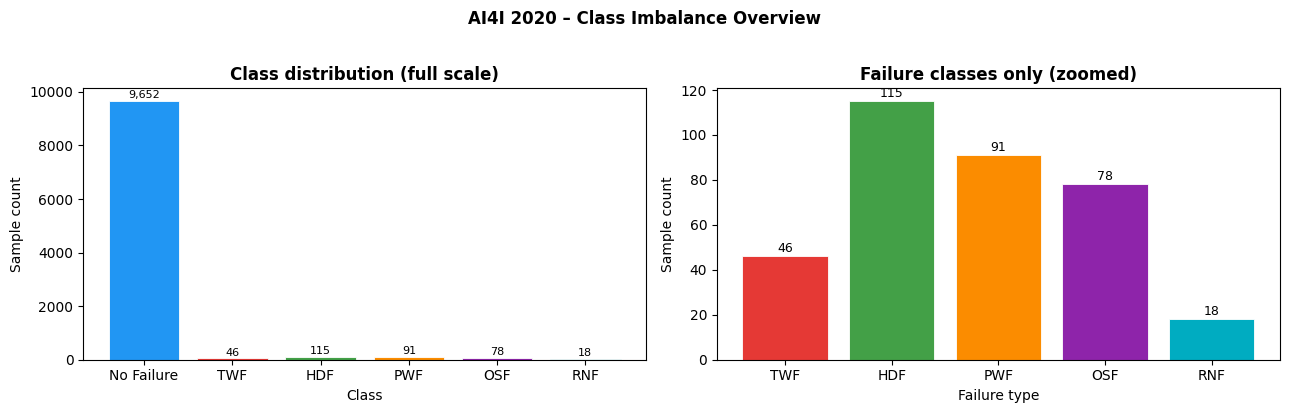

In [5]:
# ── Visualise class distribution ─────────────────────────────────────────────
colours = ["#2196F3", "#E53935", "#43A047", "#FB8C00", "#8E24AA", "#00ACC1"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full scale
axes[0].bar(class_names, dist.values, color=colours, edgecolor="white", linewidth=0.6)
axes[0].set_title("Class distribution (full scale)", fontweight="bold")
axes[0].set_ylabel("Sample count")
axes[0].set_xlabel("Class")
for bar, v in zip(axes[0].patches, dist.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 30,
                 f"{v:,}", ha="center", va="bottom", fontsize=8)

# Right: failure classes only (zoom)
axes[1].bar(class_names[1:], dist.values[1:], color=colours[1:], edgecolor="white", linewidth=0.6)
axes[1].set_title("Failure classes only (zoomed)", fontweight="bold")
axes[1].set_ylabel("Sample count")
axes[1].set_xlabel("Failure type")
for bar, v in zip(axes[1].patches, dist.values[1:]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                 f"{v}", ha="center", va="bottom", fontsize=9)

plt.suptitle("AI4I 2020 – Class Imbalance Overview",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 2 · Feature Selection & Stratified Train / Test Split

**Features used** (all numerical):
- Air temperature (K)
- Process temperature (K)
- Rotational speed (RPM)
- Torque (Nm)
- Tool wear (min)

The binary `Machine failure` column and the individual failure-flag columns are **excluded** — they would directly leak the label.

`stratify=y` preserves the original class ratios in both partitions.

In [10]:
# ── Normalise column names (handles minor CSV version differences) ────────────
rename_map = {
    "Air temperature(K)"      : "Air temperature [K]",
    "Process temperature(K)"  : "Process temperature [K]",
    "Rotational speed(rpm)"   : "Rotational speed [rpm]",
    "Torque(Nm)"              : "Torque [Nm]",
    "Tool wear(min)"          : "Tool wear [min]",
}
df.rename(columns=rename_map, inplace=True)

feature_cols = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
]

X = df[feature_cols].values
y = df["target"].values

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 8,000
Test samples     : 2,000
Features         : 5


---
## 3 · Pre-processing + SMOTE Oversampling

**StandardScaler** is fit on the training set only and then applied to the test set — this prevents any statistics from the test set leaking into the model.

**SMOTE** synthesises new minority-class samples by interpolating between real neighbours in feature space.  
`k_neighbors` is capped at `(min_class_count − 1)` to avoid a crash when a class is very rare.

In [11]:
# ── Scale features ────────────────────────────────────────────────────────────
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)   # fit + transform on train
X_test_sc    = scaler.transform(X_test)         # transform only on test

# ── SMOTE oversampling ────────────────────────────────────────────────────────
min_class_count = int(np.min(np.bincount(y_train)))
k_neighbors     = max(1, min(5, min_class_count - 1))

smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f"SMOTE k_neighbors : {k_neighbors}")
print(f"Training samples after SMOTE : {X_train_res.shape[0]:,}")
print("\nClass distribution after SMOTE:")
for cls_idx, count in zip(*np.unique(y_train_res, return_counts=True)):
    print(f"  {class_names[cls_idx]:<15s}  {count:>6,}")

SMOTE k_neighbors : 5
Training samples after SMOTE : 46,332

Class distribution after SMOTE:
  No Failure        7,722
  TWF               7,722
  HDF               7,722
  PWF               7,722
  OSF               7,722
  RNF               7,722


---
## 4 · Model Training – Random Forest

Random Forest is a strong tabular baseline:
- Naturally handles multi-class problems.
- `class_weight='balanced'` adds a second layer of imbalance correction on top of SMOTE.
- 300 trees with `max_depth=15` balances bias and variance well for this dataset size.

In [12]:
clf = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 15,
    class_weight = "balanced",
    random_state = SEED,
    n_jobs       = -1,   # use all CPU cores
)

clf.fit(X_train_res, y_train_res)
print("Training complete.")

Training complete.


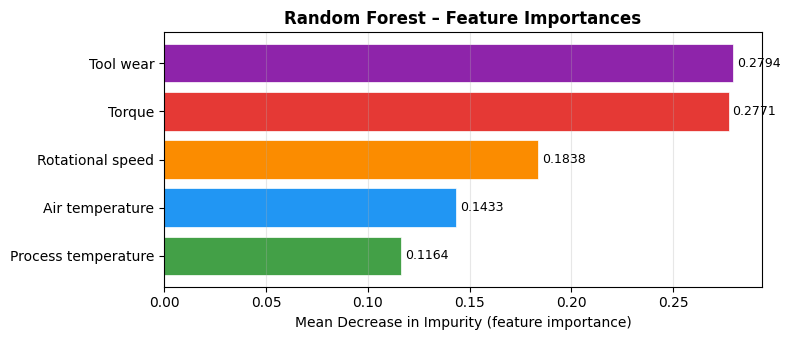

In [13]:
# ── Feature importances ───────────────────────────────────────────────────────
importances = clf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

colours_feat = ["#2196F3", "#43A047", "#FB8C00", "#E53935", "#8E24AA"]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(
    [feature_cols[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[colours_feat[i] for i in sorted_idx],
    edgecolor="white", linewidth=0.5
)
ax.invert_yaxis()
ax.set_xlabel("Mean Decrease in Impurity (feature importance)")
ax.set_title("Random Forest – Feature Importances", fontweight="bold")
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5 · Evaluation on the Test Set

We report:
1. **Overall accuracy** across all six classes.
2. **Per-class precision, recall, and F1** via `classification_report`.
3. A collapsed **binary view** — *No Failure vs. Any Failure* — which captures the operationally critical question: *"Should the machine be stopped?"*  
   **Binary recall** (fraction of real failures caught) is the most important single number here.

In [14]:
y_pred = clf.predict(X_test_sc)
y_prob = clf.predict_proba(X_test_sc)   # shape: (n_samples, 6) – used for ROC

# ── Overall accuracy ──────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy : {acc:.4f}  ({acc*100:.2f}%)\n")

# ── Per-class metrics ─────────────────────────────────────────────────────────
print(classification_report(
    y_test, y_pred,
    target_names  = class_names,
    zero_division = 0,
))

Overall Accuracy : 0.9010  (90.10%)

              precision    recall  f1-score   support

  No Failure       0.99      0.91      0.95      1930
         TWF       0.07      0.33      0.11         9
         HDF       0.69      0.78      0.73        23
         PWF       0.78      0.78      0.78        18
         OSF       0.65      0.94      0.77        16
         RNF       0.00      0.00      0.00         4

    accuracy                           0.90      2000
   macro avg       0.53      0.62      0.56      2000
weighted avg       0.98      0.90      0.94      2000



In [15]:
# ── Binary view : No Failure vs. Any Failure ──────────────────────────────────
y_test_binary = (y_test != 0).astype(int)
y_pred_binary = (y_pred != 0).astype(int)

p  = precision_score(y_test_binary, y_pred_binary, zero_division=0)
r  = recall_score   (y_test_binary, y_pred_binary, zero_division=0)
f1 = f1_score       (y_test_binary, y_pred_binary, zero_division=0)

print("Binary view – No Failure vs. Any Failure")
print("-" * 40)
print(f"  Precision : {p:.4f}")
print(f"  Recall    : {r:.4f}  ← fraction of real failures caught")
print(f"  F1        : {f1:.4f}")

Binary view – No Failure vs. Any Failure
----------------------------------------
  Precision : 0.2294
  Recall    : 0.7571  ← fraction of real failures caught
  F1        : 0.3522


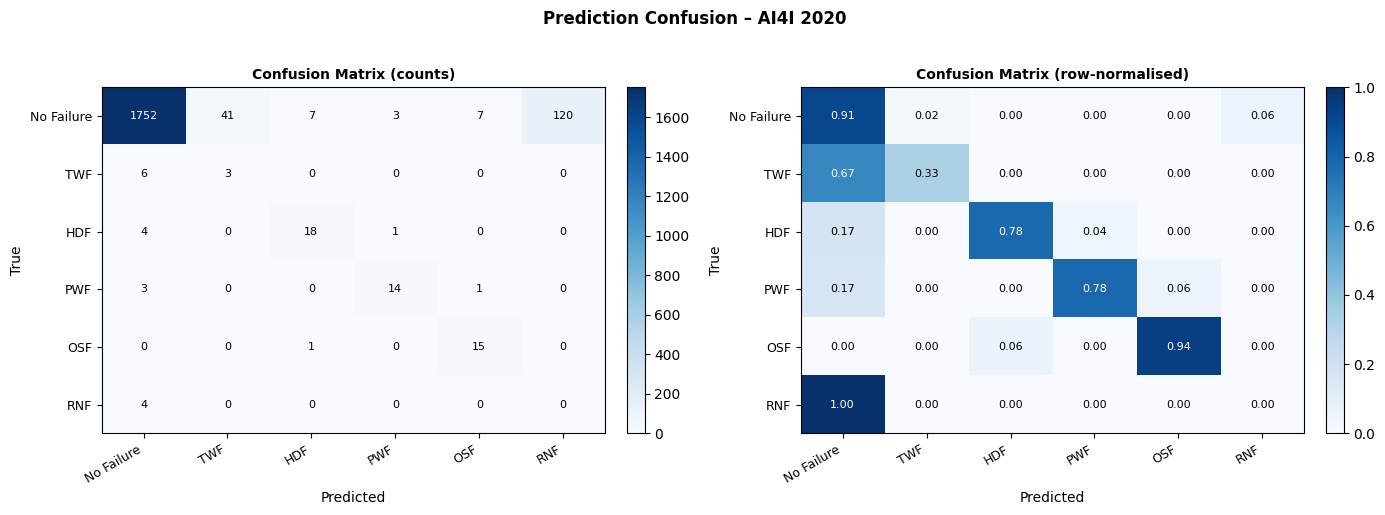

In [16]:
# ── Confusion matrix heatmap ──────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors

cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ["d", ".2f"],
    ["Confusion Matrix (counts)", "Confusion Matrix (row-normalised)"],
):
    im = ax.imshow(data, cmap="Blues", aspect="auto",
                   vmin=0, vmax=data.max())
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    thresh = data.max() / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            colour = "white" if data[i, j] > thresh else "black"
            ax.text(j, i, format(data[i, j], fmt),
                    ha="center", va="center", fontsize=8, color=colour)

plt.suptitle("Prediction Confusion – AI4I 2020",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 6 · ROC Curves (One-vs-Rest, per class)

`label_binarize` converts the six-class vector into a binary matrix `(n_samples × 6)`.  
We then compute a separate ROC curve for each class under the **one-vs-rest** scheme, plus a **micro-average** curve that treats every sample-class pair equally.

The second panel zooms the x-axis to the `[0, 0.30]` FPR range so the failure-class curves are not squashed against the y-axis.

In [17]:
n_classes  = len(class_names)
palette    = ["#2196F3", "#E53935", "#43A047", "#FB8C00", "#8E24AA", "#00ACC1"]
lw         = 1.8

# Binarise labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# Compute ROC and AUC per class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# Micro-average (flattens all class columns into one)
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(), y_prob.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print("AUC per class:")
for i, name in enumerate(class_names):
    print(f"  {name:<15s}  {roc_auc[i]:.4f}")
print(f"  {'Micro-avg':<15s}  {roc_auc['micro']:.4f}")

AUC per class:
  No Failure       0.9279
  TWF              0.9663
  HDF              0.9979
  PWF              0.9988
  OSF              0.9979
  RNF              0.4770
  Micro-avg        0.9949


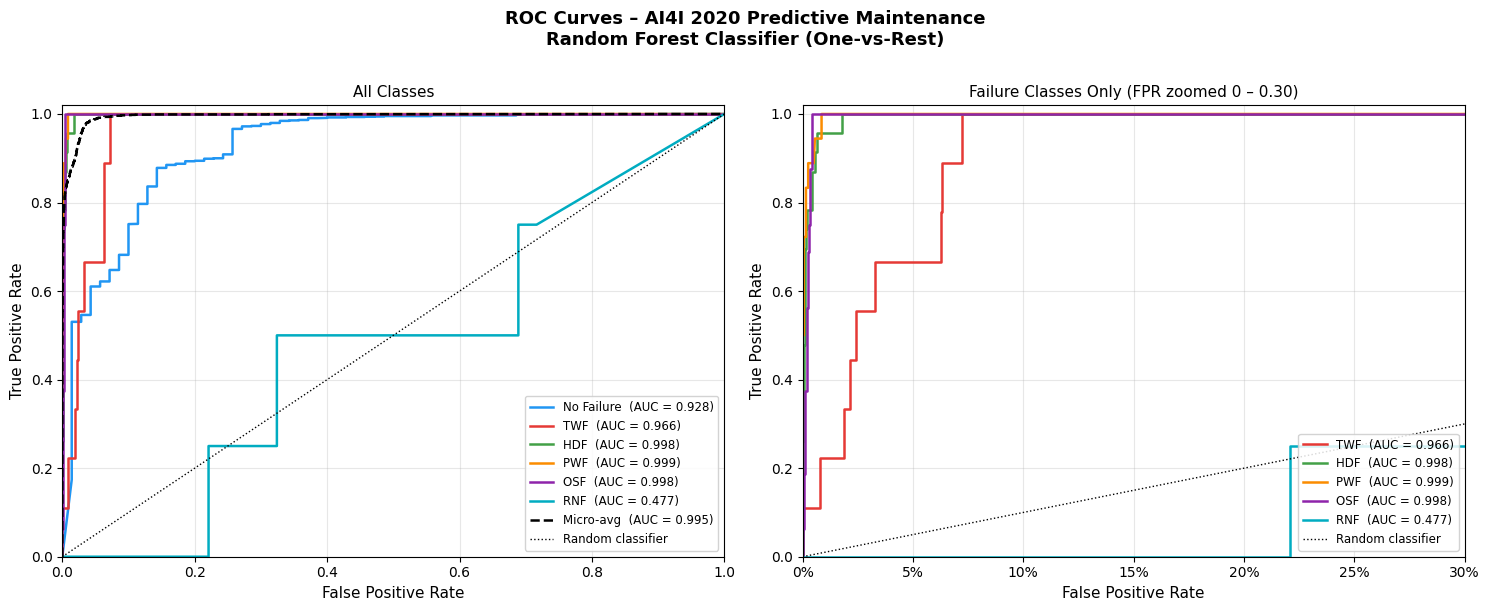

ROC curve saved to 'roc_curve.png'


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "ROC Curves – AI4I 2020 Predictive Maintenance\n"
    "Random Forest Classifier (One-vs-Rest)",
    fontsize=13, fontweight="bold", y=1.01
)

# ── Left: all six classes ─────────────────────────────────────────────────────
ax = axes[0]
for i, (name, colour) in enumerate(zip(class_names, palette)):
    ax.plot(fpr[i], tpr[i], color=colour, lw=lw,
            label=f"{name}  (AUC = {roc_auc[i]:.3f})")

ax.plot(fpr["micro"], tpr["micro"], color="black", lw=lw, linestyle="--",
        label=f"Micro-avg  (AUC = {roc_auc['micro']:.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1, label="Random classifier")
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("All Classes", fontsize=11)
ax.legend(loc="lower right", fontsize=8.5, framealpha=0.85)
ax.grid(True, alpha=0.3)

# ── Right: failure classes zoomed ────────────────────────────────────────────
ax2 = axes[1]
for i in range(1, n_classes):      # skip class 0 (No Failure)
    ax2.plot(fpr[i], tpr[i], color=palette[i], lw=lw,
             label=f"{class_names[i]}  (AUC = {roc_auc[i]:.3f})")

ax2.plot([0, 1], [0, 1], "k:", lw=1, label="Random classifier")
ax2.set_xlim([0.0, 0.30]); ax2.set_ylim([0.0, 1.02])
ax2.set_xlabel("False Positive Rate", fontsize=11)
ax2.set_ylabel("True Positive Rate", fontsize=11)
ax2.set_title("Failure Classes Only (FPR zoomed 0 – 0.30)", fontsize=11)
ax2.legend(loc="lower right", fontsize=8.5, framealpha=0.85)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC curve saved to 'roc_curve.png'")

---
## 7 · Summary

In [19]:
print("=" * 55)
print("RESULTS SUMMARY")
print("=" * 55)
print(f"  Test accuracy            : {acc*100:.2f}%")
print(f"  Micro-avg ROC-AUC        : {roc_auc['micro']:.4f}")
print(f"  Binary recall (failures) : {r:.4f}  "
      f"({'✓ good' if r >= 0.80 else '✗ needs improvement'})")
print()
print(f"  {'Class':<15s}  {'AUC':>6}")
print("  " + "-" * 24)
for i, name in enumerate(class_names):
    print(f"  {name:<15s}  {roc_auc[i]:.4f}")
print("=" * 55)

RESULTS SUMMARY
  Test accuracy            : 90.10%
  Micro-avg ROC-AUC        : 0.9949
  Binary recall (failures) : 0.7571  (✗ needs improvement)

  Class               AUC
  ------------------------
  No Failure       0.9279
  TWF              0.9663
  HDF              0.9979
  PWF              0.9988
  OSF              0.9979
  RNF              0.4770
